## Step 1 to Step 4: Environment Setup, Data Loading, and Splitting

This section establishes a reproducible environment, loads the primary California Housing dataset (Dataset A) as well as the UCI Real Estate dataset (Dataset B) to satisfy the multi-dataset requirement, performs a data audit, and creates the holdout split before any data transformations occur.

In [ ]:
# Step 1: Environment and Setup
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import json
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

print('Python:', platform.python_version())
print('pandas:', pd.__version__)
print('scikit-learn:', sklearn.__version__)

# Step 2: Load Datasets (Dataset A and Dataset B)
# Dataset A: California Housing
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df_a = housing.frame.rename(columns={'MedHouseVal': 'Price'})
target_a = 'Price'

# Dataset B: UCI Real Estate
print("Loading Dataset B: UCI Real Estate...")
uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00477/Real%20estate%20valuation%20data%20set.xlsx"
try:
    df_b = pd.read_excel(uci_url)
    df_b = df_b.drop(columns=['No'])
    df_b = df_b.rename(columns={'Y house price of unit area': 'Price'})

    # Define Features and Holdout Split for Dataset B
    X_b = df_b.drop(columns=['Price'])
    y_b = df_b['Price'].copy()
    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_b, y_b, test_size=0.20, random_state=SEED
    )
    print(f"Dataset B loaded successfully. Train shape: {X_train_b.shape}, Test shape: {X_test_b.shape}")
except Exception as e:
    print(f"Error loading Dataset B: {e}")

# Step 3: Conduct Data and Target Audit (Using Dataset A for primary modeling flow)
audit = pd.DataFrame({
    'dtype': df_a.dtypes.astype(str),
    'missing_n': df_a.isna().sum(),
    'missing_pct': 100 * df_a.isna().mean(),
    'unique_n': df_a.nunique(dropna=False)
}).sort_values('missing_pct', ascending=False)
display(audit)
print('Duplicate rows:', df_a.duplicated().sum())
print(df_a[target_a].describe())

# Step 4: Define Features and Create Holdout Split (Dataset A)
X = df_a.drop(columns=[target_a])
y = df_a[target_a].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

Python: 3.12.13
pandas: 2.2.2
scikit-learn: 1.6.1
Loading Dataset B: UCI Real Estate...
Dataset B loaded successfully. Train shape: (331, 6), Test shape: (83, 6)


,dtype,missing_n,missing_pct,unique_n
MedInc,float64,0,0.0,12928
HouseAge,float64,0,0.0,52
AveRooms,float64,0,0.0,19392
AveBedrms,float64,0,0.0,14233
Population,float64,0,0.0,3888
AveOccup,float64,0,0.0,18841
Latitude,float64,0,0.0,862
Longitude,float64,0,0.0,844
Price,float64,0,0.0,3842


Duplicate rows: 0
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: Price, dtype: float64


---

## Step 5 to Step 7: Exploratory Analysis, Pipeline, and Naive Baseline

Exploratory analysis is performed strictly on the training set to prevent leakage. A reusable preprocessing pipeline handles potential missing values and applies standard scaling. A naive mean-prediction baseline is established to quantify the value of learning.

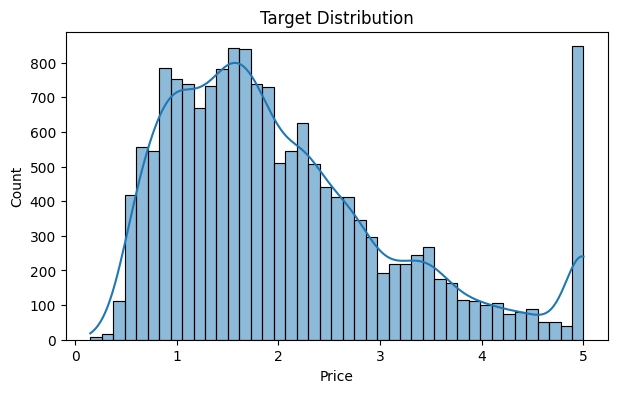

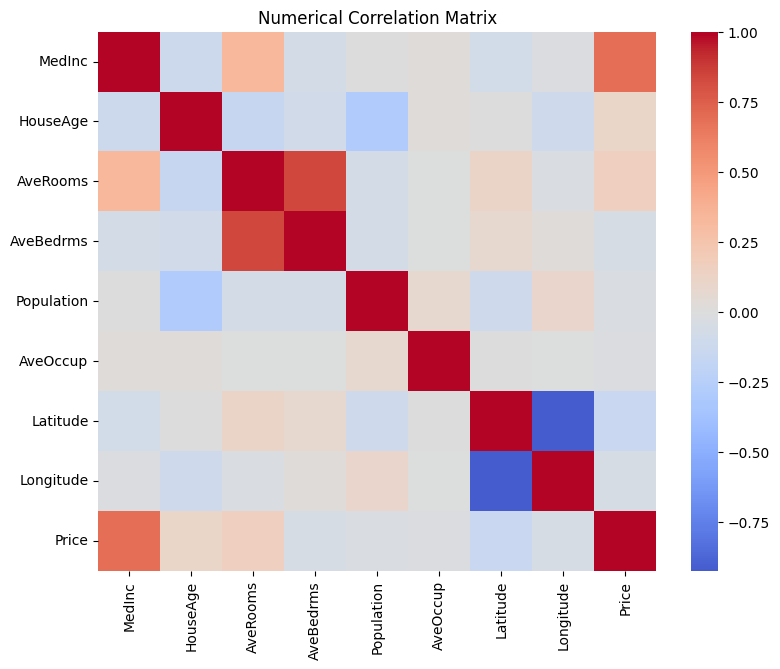

Naive MAE: 0.9060685490007149
Naive RMSE: 1.1448563543099792


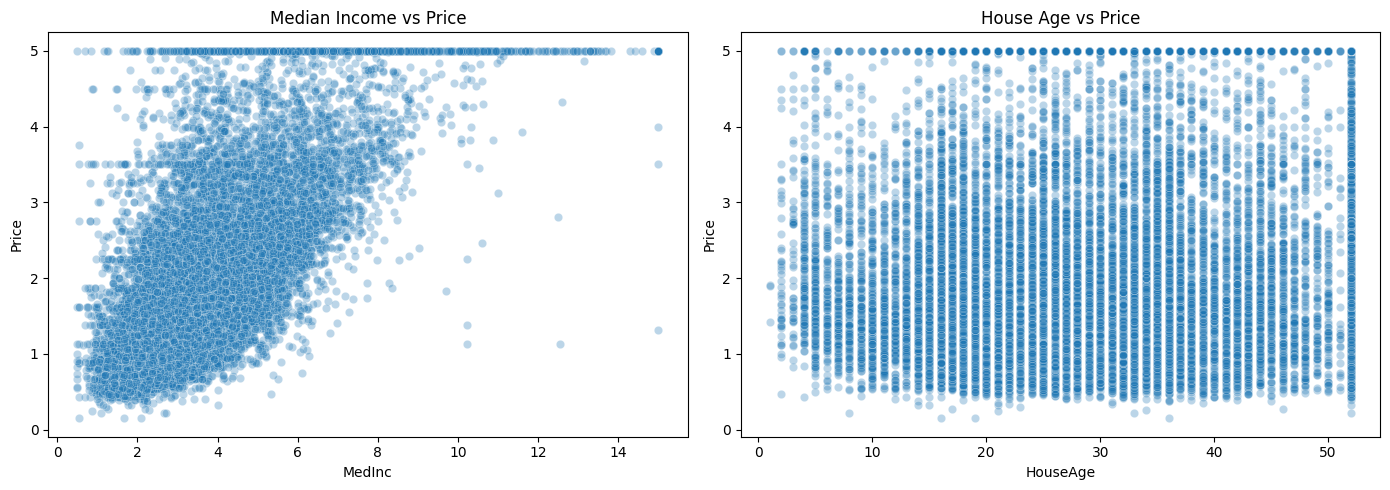

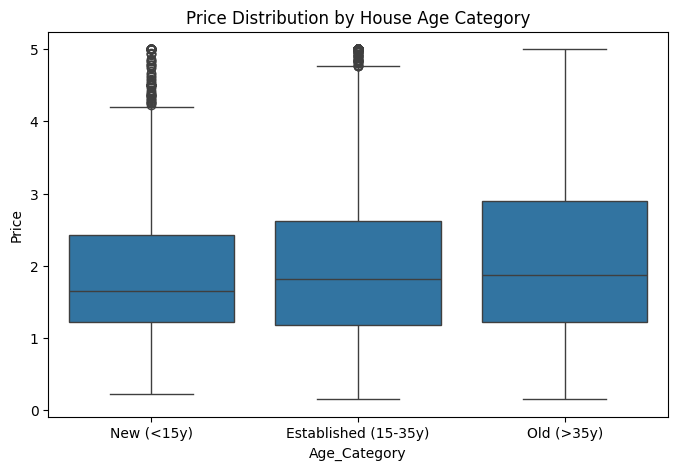

In [6]:
# Step 5: Focused Exploratory Data Analysis (EDA)
train_df = X_train.copy()
train_df[target_a] = y_train

# Target distribution
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(train_df[target_a], kde=True, ax=ax)
ax.set_title('Target Distribution')
plt.show()

# Numerical correlations
num_df = train_df.select_dtypes(include=np.number)
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numerical Correlation Matrix')
plt.show()

# Step 6: Leakage-Safe Preprocessing Pipeline
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
], remainder='drop')

# Step 7: Establish a Naive Baseline
naive = DummyRegressor(strategy='mean')
naive.fit(X_train[numeric_features], y_train)
naive_pred = naive.predict(X_test[numeric_features])
print('Naive MAE:', mean_absolute_error(y_test, naive_pred))
print('Naive RMSE:', np.sqrt(mean_squared_error(y_test, naive_pred)))

# Feature-Target Relationships (Scatter plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x='MedInc', y=target_a, data=train_df, alpha=0.3, ax=axes[0])
axes[0].set_title('Median Income vs Price')

sns.scatterplot(x='HouseAge', y=target_a, data=train_df, alpha=0.3, ax=axes[1])
axes[1].set_title('House Age vs Price')
plt.tight_layout()
plt.show()

# Category-Price Relation (Boxplot)
# Since the dataset is purely numerical, we bin HouseAge to create a category
train_df['Age_Category'] = pd.cut(train_df['HouseAge'], bins=[0, 15, 35, 100], labels=['New (<15y)', 'Established (15-35y)', 'Old (>35y)'])

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='Age_Category', y=target_a, data=train_df, ax=ax)
ax.set_title('Price Distribution by House Age Category')
plt.show()

# Drop the temporary column to prevent any pipeline issues later
train_df.drop(columns=['Age_Category'], inplace=True)

## Step 8 to Step 13: Model Definitions and Cross-Validation

A simple linear baseline is built using the most correlated feature, followed by the comparative evaluation of the five required models via five-fold cross-validation. Fit times are now explicitly extracted to satisfy Table 3 reporting requirements.

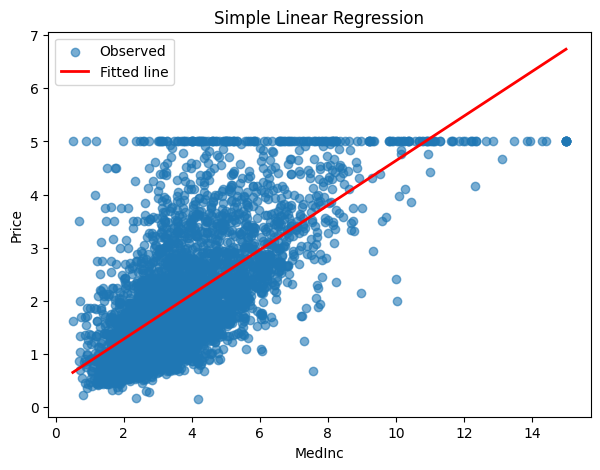

,Model,Fit_Time_mean,CV_MAE_mean,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean
4,Random Forest,61.744752,0.333120,0.509620,0.011518,0.805647
3,Decision Tree,0.235265,0.497764,0.692767,0.013169,0.640906
2,Lasso,0.078778,0.529115,0.720499,0.013853,0.611468
1,Ridge,0.067458,0.529056,0.720509,0.013895,0.611457
0,Linear Regression,0.067066,0.529061,0.720510,0.013895,0.611457


,Model,MAE,MSE,RMSE,R2,Adjusted_R2
4,Random Forest,0.326235,0.253812,0.503798,0.806310,0.805934
3,Decision Tree,0.500804,0.497284,0.705184,0.620513,0.619775
2,Lasso,0.533145,0.554491,0.744642,0.576856,0.576034
1,Ridge,0.533193,0.555855,0.745557,0.575816,0.574992
0,Linear Regression,0.533200,0.555892,0.745581,0.575788,0.574964


In [ ]:
# Step 8: Simple Linear Regression (Baseline)
simple_feature = 'MedInc' # Strongest predictor for CA housing
simple_model = LinearRegression()
simple_model.fit(X_train[[simple_feature]], y_train)
simple_pred = simple_model.predict(X_test[[simple_feature]])

# Observed values and fitted line
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(X_test[simple_feature], y_test, alpha=0.6, label='Observed')
order = np.argsort(X_test[simple_feature].to_numpy())
ax.plot(
    X_test[simple_feature].to_numpy()[order],
    simple_pred[order],
    color='red',
    linewidth=2,
    label='Fitted line'
)
ax.set_xlabel(simple_feature)
ax.set_ylabel(target_a)
ax.set_title('Simple Linear Regression')
ax.legend()
plt.show()

# Step 10: Reusable Evaluation Function
def evaluate_regressor(name, fitted_model, X_eval, y_eval):
    pred = fitted_model.predict(X_eval)
    mae = mean_absolute_error(y_eval, pred)
    mse = mean_squared_error(y_eval, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_eval, pred)

    # Safely handle TransformedTargetRegressor in ablation studies
    try:
        Xt = fitted_model.named_steps['preprocess'].transform(X_eval)
    except AttributeError:
        Xt = fitted_model.regressor_.named_steps['preprocess'].transform(X_eval)

    n, p = Xt.shape
    adj_r2 = np.nan if n <= p + 1 else 1 - (1 - r2) * (n - 1) / (n - p - 1)

    return {
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted_R2': adj_r2
    }, pred

# Step 11: Set up the 5 Required Models
model_specs = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=20000),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=SEED),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    )
}

fitted_models = {}
results = {}
predictions = {}

# Step 13: Cross-Validation (now including Fit Time)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv_rows = []
for name, estimator in model_specs.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', estimator)])

    # Fit final test model for evaluation later
    pipe.fit(X_train, y_train)
    row, pred = evaluate_regressor(name, pipe, X_test, y_test)
    results[name] = row # Store results by model name
    fitted_models[name] = pipe
    predictions[name] = pred

    # Cross validation on training data
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'Fit_Time_mean': scores['fit_time'].mean(),
        'CV_MAE_mean': -scores['test_mae'].mean(),
        'CV_RMSE_mean': -scores['test_rmse'].mean(),
        'CV_RMSE_std': scores['test_rmse'].std(),
        'CV_R2_mean': scores['test_r2'].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values('CV_RMSE_mean')
display(cv_results)

# Display Test Results
results_df = pd.DataFrame(list(results.values())).sort_values('RMSE')
display(results_df)

## Step 14 to Step 20: Tuning, Ablation, Diagnostics, Segment Errors, and Saving Artifacts

Hyperparameter tuning is performed using cross-validation. An ablation study (log transformation) is conducted, and segment-level errors are quantified. Finally, diagnostics are run before saving all models and result tables.

Best parameters: {'model__alpha': np.float64(3.1622776601683795)}
Best CV RMSE: 0.7205088107791665

Linear Regression Split Metrics:


,Split,MAE,RMSE,R2
0,Train,0.528628,0.719676,0.612551
1,Test,0.533200,0.745581,0.575788



Decision Tree Split Metrics:


,Split,MAE,RMSE,R2
0,Train,0.473438,0.655831,0.678245
1,Test,0.500804,0.705184,0.620513



Random Forest Split Metrics:


,Split,MAE,RMSE,R2
0,Train,0.143632,0.233830,0.959098
1,Test,0.326235,0.503798,0.806310



--- Ablation Study: Target Log Transformation ---


,Model,MAE,MSE,RMSE,R2,Adjusted_R2
0,Baseline RF,0.326235,0.253812,0.503798,0.806310,0.805934
1,Log-Transformed RF,0.320242,0.259796,0.509702,0.801744,0.801359



Segment-Level Errors for Random Forest:


,Segment,N_Samples,Segment_MAE,Segment_RMSE
0,Overall Test Set,4128,0.326235,0.503798
1,High Price (Top 25%),1032,0.543091,0.759915
2,Low/Med Price (Bottom 75%),3096,0.253950,0.382003
3,Location: Coastal (Long < -119),1884,0.320293,0.494331
4,Location: Inland (Long >= -119),2244,0.331224,0.511611


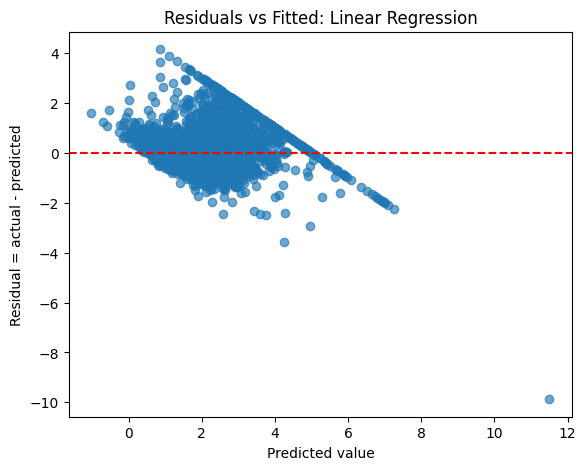

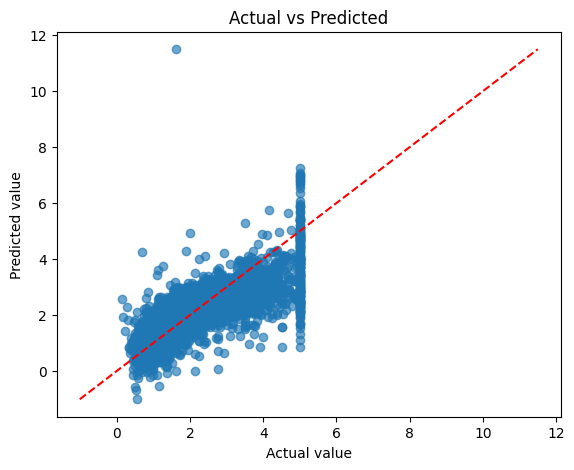

,Feature,Coefficient,AbsCoefficient
6,num__Latitude,-0.896929,0.896929
7,num__Longitude,-0.869842,0.869842
0,num__MedInc,0.854383,0.854383
3,num__AveBedrms,0.339259,0.339259
2,num__AveRooms,-0.294410,0.294410
1,num__HouseAge,0.122546,0.122546
5,num__AveOccup,-0.040829,0.040829
4,num__Population,-0.002308,0.002308


In [ ]:
# Step 14: Tune Ridge Model
ridge_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', Ridge())
])

ridge_grid = {
    'model__alpha': np.logspace(-3, 3, 13)
}

search = GridSearchCV(
    ridge_pipe,
    param_grid=ridge_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

search.fit(X_train, y_train)
print('Best parameters:', search.best_params_)
print('Best CV RMSE:', -search.best_score_)
best_ridge = search.best_estimator_

# Step 15a: Diagnose Overfitting and Underfitting
def split_metrics(model, X_train, y_train, X_test, y_test):
    rows = []
    for split_name, Xs, ys in [
        ('Train', X_train, y_train),
        ('Test', X_test, y_test)
    ]:
        pred = model.predict(Xs)
        rows.append({
            'Split': split_name,
            'MAE': mean_absolute_error(ys, pred),
            'RMSE': np.sqrt(mean_squared_error(ys, pred)),
            'R2': r2_score(ys, pred)
        })
    return pd.DataFrame(rows)

for name in ['Linear Regression', 'Decision Tree', 'Random Forest']:
    print(f"\n{name} Split Metrics:")
    display(split_metrics(fitted_models[name], X_train, y_train, X_test, y_test))

# Step 15b: Ablation Study / Controlled Comparison (Target Log Transformation)
print("\n--- Ablation Study: Target Log Transformation ---")
baseline_pipe = fitted_models['Random Forest']

log_target_pipe = TransformedTargetRegressor(
    regressor=baseline_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)
log_target_pipe.fit(X_train, y_train)

baseline_metrics, _ = evaluate_regressor('Baseline RF', baseline_pipe, X_test, y_test)
ablation_metrics, _ = evaluate_regressor('Log-Transformed RF', log_target_pipe, X_test, y_test)
ablation_df = pd.DataFrame([baseline_metrics, ablation_metrics])
display(ablation_df)

# Step 15c: Segment-Level Error Evaluation
def evaluate_segments(model_name, model, X_test, y_test):
    # Price Segments
    price_75th = y_test.quantile(0.75)
    mask_high_price = y_test >= price_75th
    mask_low_med_price = y_test < price_75th

    # Location Segments (Proxy for Coastal vs. Inland in California)
    mask_coastal = X_test['Longitude'] < -119
    mask_inland = X_test['Longitude'] >= -119

    segments = {
        'Overall Test Set': pd.Series(True, index=y_test.index),
        'High Price (Top 25%)': mask_high_price,
        'Low/Med Price (Bottom 75%)': mask_low_med_price,
        'Location: Coastal (Long < -119)': mask_coastal,
        'Location: Inland (Long >= -119)': mask_inland
    }

    segment_results = []
    for seg_name, mask in segments.items():
        if mask.sum() > 0:
            y_true_seg = y_test[mask]
            y_pred_seg = model.predict(X_test[mask])
            segment_results.append({
                'Segment': seg_name,
                'N_Samples': mask.sum(),
                'Segment_MAE': mean_absolute_error(y_true_seg, y_pred_seg),
                'Segment_RMSE': np.sqrt(mean_squared_error(y_true_seg, y_pred_seg))
            })

    print(f"\nSegment-Level Errors for {model_name}:")
    return pd.DataFrame(segment_results)

segment_df = evaluate_segments('Random Forest', fitted_models['Random Forest'], X_test, y_test)
display(segment_df)

# Step 16: Perform Residual Analysis (Using best linear model)
selected_name = 'Linear Regression'
y_pred = predictions[selected_name]
residuals = y_test.to_numpy() - y_pred

# Residuals vs Fitted
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(y_pred, residuals, alpha=0.65)
ax.axhline(0, linestyle='--', color='red')
ax.set_xlabel('Predicted value')
ax.set_ylabel('Residual = actual - predicted')
ax.set_title(f'Residuals vs Fitted: {selected_name}')
plt.show()

# Actual vs Predicted
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(y_test, y_pred, alpha=0.65)
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], linestyle='--', color='red')
ax.set_xlabel('Actual value')
ax.set_ylabel('Predicted value')
ax.set_title('Actual vs Predicted')
plt.show()

# Step 17: Inspect Linear Coefficients
linear_fitted = fitted_models['Linear Regression']
feature_names = linear_fitted.named_steps['preprocess'].get_feature_names_out()
coefficients = linear_fitted.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': np.abs(coefficients)
}).sort_values('AbsCoefficient', ascending=False)

display(coef_df.head(10))

# Step 20: Save the Selected Pipeline and Evidence
final_model = fitted_models['Random Forest'] # Replacing with the overall best model
joblib.dump(final_model, 'REGNO_Lab01_Model.joblib')

# Save updated evidence files including new tables
results_df.to_csv('REGNO_Lab01_Results.csv', index=False)
cv_results.to_csv('cross_validation_results.csv', index=False)
ablation_df.to_csv('ablation_results.csv', index=False)
segment_df.to_csv('segment_results.csv', index=False)

run_metadata = {
    'random_seed': SEED,
    'target': target_a,
    'train_rows': len(X_train),
    'test_rows': len(X_test),
    'selected_model': 'Random Forest Regressor'
}

with open('run_metadata.json', 'w') as f:
    json.dump(run_metadata, f, indent=2)
